In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

data = pd.read_csv('/Users/gopesh/Documents/Machine Learning/PROJECTS/o5_bikes_data_cleaned.csv')
data.head()

,title,reg_year,brand_name,model,kilometer,fuel_type,owner,city,color,insurance,mileage_arai,mileage_owner_reported,riding_range,cylinders,front_brake_type,rear_brake_type,tyre_type,fuel_tank_capacity,reserve_fuel_capacity,price
0,2011 Hero Honda Splendor Drum,2011,Hero Honda,Splendor Drum,50000,Not Available,First,Bhopal,Black,Comprehensive,NaN,NaN,NaN,NaN,Not Available,Not Available,Not Available,NaN,NaN,10000.0
1,2021 Ducati Monster Standard,2021,Ducati,Monster Standard,2700,Petrol,Second,Mumbai,Dark Stealth,Not Available,19.0,NaN,266.0,2.0,Disc,Disc,Tubeless,14.0,3.5,1050000.0
2,2022 Bajaj Pulsar Dual Channel ABS [2022],2022,Bajaj,Pulsar Dual Channel ABS [],30009,Petrol,First,Kolkata,Brooklyn Black,Comprehensive,51.6,46.0,722.0,1.0,Disc,Disc,Tubeless,14.0,2.8,120000.0
3,2019 Yamaha FZ Single Channel ABS,2019,Yamaha,FZ Single Channel ABS,50244,Petrol,First,Chennai,BLACK,Not Available,58.0,46.0,696.0,1.0,Disc,Drum,Tubeless,12.0,NaN,65000.0
4,2019 TVS Apache Carburetor ABS - Smart Xonnect,2019,TVS,Apache Carburetor ABS - Smart Xonnect,28000,Petrol,First,Bhopal,Black,Not Available,NaN,38.0,NaN,1.0,Disc,Disc,Tubeless,12.0,2.5,80000.0


## Column types - 
1. Numerical - reg_year , kilometer , mileage_arai , mileage_owner_reported , riding_range , cylinders , fuel_tank_capacity , reserve_fuel_capacity , price
2. Categorical - brand_name , fuel_type , owner , city , color , insurance , front_brake_types , rear_brake_type , tyre_type 
3. Mixed - model 

In [5]:
data['brand_name'].value_counts()

brand_name
Bajaj              457
Honda              369
Royal Enfield      365
TVS                340
Hero               332
Yamaha             285
Suzuki             132
KTM                 88
Jawa                68
Unknown             53
Hero Honda          51
OLA                 40
BMW                 34
Yezdi               22
Triumph             18
Aprilia             17
Harley-Davidson     12
Benelli             10
Mahindra             7
Kawasaki             6
Ducati               5
Husqvarna            3
Ampere Magnus        1
Keeway               1
Name: count, dtype: int64

In [6]:
brands = ["Harley-Davidson","Royal Enfield","Hero Honda","TVS Motor","Moto Guzzi","CFMoto","Husqvarna","Kawasaki","Triumph","Mahindra","Benelli","Keeway","Aprilia","Suzuki",
          "Yamaha","Bajaj","Honda","Hero","TVS","KTM","Jawa","Yezdi","BMW","Ducati","Indian","Ampere Magnus","OLA",
          "Ather","Okinawa","Revolt","Ampere","Ola","Vida","Joy e-bike","PURE EV","Evolet","Bounce","Odysse","Ultraviolette",
          "Vespa","UM","Benling","BSA"]
def extract(title) : 
    for brand in brands : 
        if brand.lower() in title.lower() : 
            return brand
    return "Unknown"
data['brand_name'] = data['title'].apply(extract)
data['brand_name'].value_counts()

brand_name
Bajaj              457
Honda              369
Royal Enfield      365
TVS                340
Hero               332
Yamaha             285
Suzuki             132
KTM                 88
Jawa                68
Hero Honda          51
OLA                 40
BMW                 34
Yezdi               22
Triumph             18
Aprilia             17
Revolt              14
Harley-Davidson     12
Vespa               11
Benelli             10
UM                   7
Mahindra             7
Kawasaki             6
Ducati               5
Ather                5
Okinawa              4
Husqvarna            3
Evolet               2
Bounce               2
Joy e-bike           1
Odysse               1
Keeway               1
BSA                  1
PURE EV              1
Vida                 1
Benling              1
Ampere Magnus        1
Unknown              1
Ultraviolette        1
Name: count, dtype: int64

In [7]:
data1 = data.copy()
rare = data1['brand_name'].value_counts()
rare = rare[rare < 5].index

data1['brand_name'] = data1['brand_name'].apply(lambda x: 'Other' if x in rare else x)
data1['brand_name'].value_counts()
data = data1

## Column types - 
1. Numerical - reg_year , kilometer , mileage_arai , mileage_owner_reported , riding_range , cylinders , fuel_tank_capacity , reserve_fuel_capacity , price
2. Categorical - brand_name , fuel_type , owner , city , color , insurance , front_brake_types , rear_brake_type , tyre_type 
3. Mixed - model

### --> reg_year 
1. Removed reg_year and generated a new column bike_age.
2. Data is little bit skewed, but it is fine.

In [8]:
data['reg_year'].describe()

count    2716.000000
mean     2019.412739
std         4.553521
min      1983.000000
25%      2017.000000
50%      2020.000000
75%      2023.000000
max      2026.000000
Name: reg_year, dtype: float64

<Axes: ylabel='Frequency'>

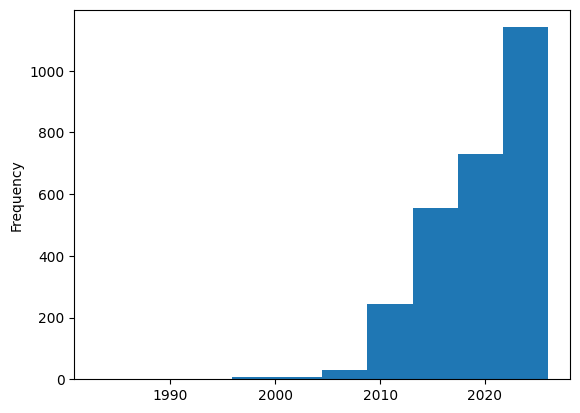

In [9]:
data['reg_year'].plot(kind = 'hist')

In [10]:
# creating the age of the bike column
data['bike_age'] = 2026 - data['reg_year']
data['bike_age'].describe()

count    2716.000000
mean        6.587261
std         4.553521
min         0.000000
25%         3.000000
50%         6.000000
75%         9.000000
max        43.000000
Name: bike_age, dtype: float64

In [11]:
data.drop(['reg_year'], axis = 1, inplace = True)
col = data.pop('bike_age')
data.insert(3, 'bike_age', col)
data.head()

,title,brand_name,model,bike_age,kilometer,fuel_type,owner,city,color,insurance,mileage_arai,mileage_owner_reported,riding_range,cylinders,front_brake_type,rear_brake_type,tyre_type,fuel_tank_capacity,reserve_fuel_capacity,price
0,2011 Hero Honda Splendor Drum,Hero Honda,Splendor Drum,15,50000,Not Available,First,Bhopal,Black,Comprehensive,NaN,NaN,NaN,NaN,Not Available,Not Available,Not Available,NaN,NaN,10000.0
1,2021 Ducati Monster Standard,Ducati,Monster Standard,5,2700,Petrol,Second,Mumbai,Dark Stealth,Not Available,19.0,NaN,266.0,2.0,Disc,Disc,Tubeless,14.0,3.5,1050000.0
2,2022 Bajaj Pulsar Dual Channel ABS [2022],Bajaj,Pulsar Dual Channel ABS [],4,30009,Petrol,First,Kolkata,Brooklyn Black,Comprehensive,51.6,46.0,722.0,1.0,Disc,Disc,Tubeless,14.0,2.8,120000.0
3,2019 Yamaha FZ Single Channel ABS,Yamaha,FZ Single Channel ABS,7,50244,Petrol,First,Chennai,BLACK,Not Available,58.0,46.0,696.0,1.0,Disc,Drum,Tubeless,12.0,NaN,65000.0
4,2019 TVS Apache Carburetor ABS - Smart Xonnect,TVS,Apache Carburetor ABS - Smart Xonnect,7,28000,Petrol,First,Bhopal,Black,Not Available,NaN,38.0,NaN,1.0,Disc,Disc,Tubeless,12.0,2.5,80000.0


<Axes: ylabel='Density'>

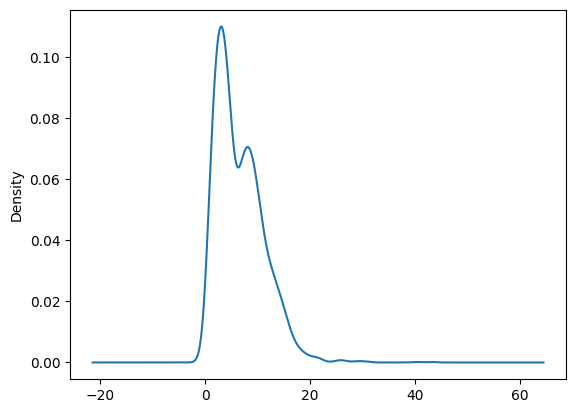

In [12]:
data['bike_age'].plot(kind = 'kde')

### --> kilometer
1. removed some outlier from the data and some outliers are genuine.
2. data is left skewed as most bikes traveled under 100,000 km.
3. some bikes had very few kilometers over a period of 5+ years so converted those values to nan

In [13]:
data['kilometer'].describe()

count      2716.000000
mean      31085.407953
std       27284.950739
min          10.000000
25%       12000.000000
50%       25000.000000
75%       43125.000000
max      351282.000000
Name: kilometer, dtype: float64

<Axes: >

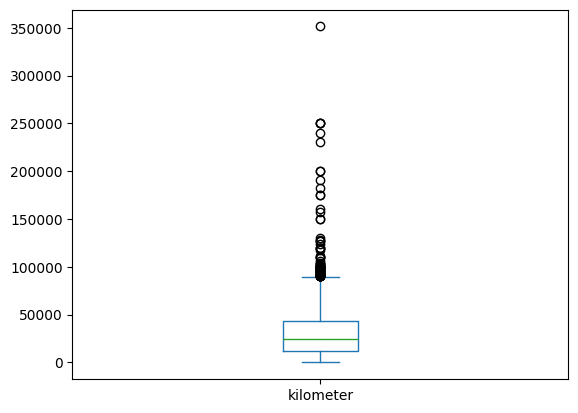

In [14]:
data['kilometer'].plot(kind='box')

<Axes: ylabel='Frequency'>

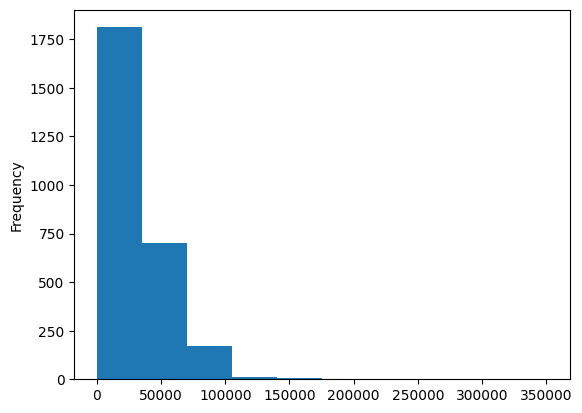

In [15]:
data['kilometer'].plot(kind='hist')

np.float64(2.6587752372567315)

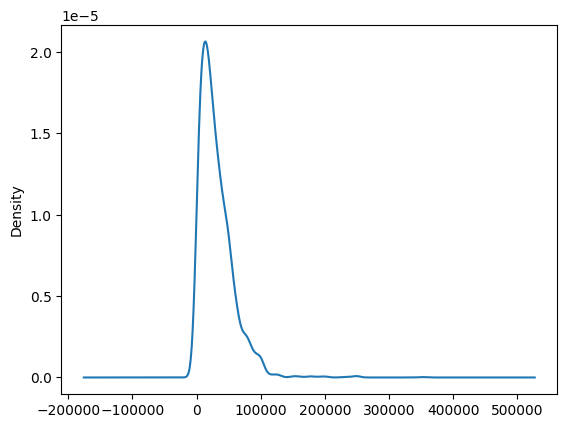

In [16]:
data['kilometer'].plot(kind='kde')
data['kilometer'].skew()

### --> mileage_arai and mileage_owner_reported
1. owner reported is perfectly fine as the data is not very skewed and two outliers is there at 75km which is fine as genuinely they have 75km mileage
2. mileage_arai consists for nearly half the missing values so we need to look at it.

In [17]:
data['mileage_arai'].describe()

count    1252.000000
mean       51.549681
std        15.905046
min        13.000000
25%        40.000000
50%        50.000000
75%        61.000000
max        95.000000
Name: mileage_arai, dtype: float64

In [18]:
data['mileage_owner_reported'].describe()

count    2496.000000
mean       44.019832
std        10.504923
min        13.000000
25%        35.000000
50%        45.000000
75%        50.000000
max        75.000000
Name: mileage_owner_reported, dtype: float64

<Axes: ylabel='Frequency'>

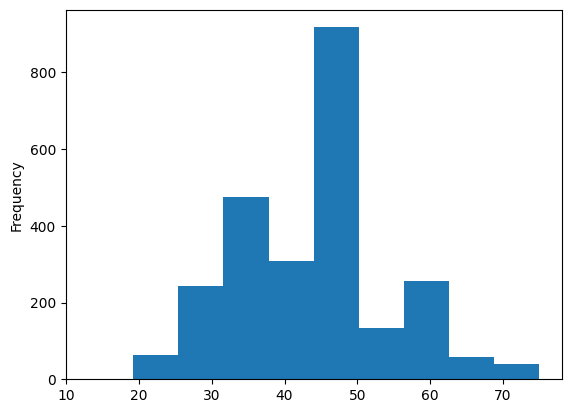

In [19]:
data['mileage_owner_reported'].plot(kind='hist')

np.float64(0.2617667997702138)

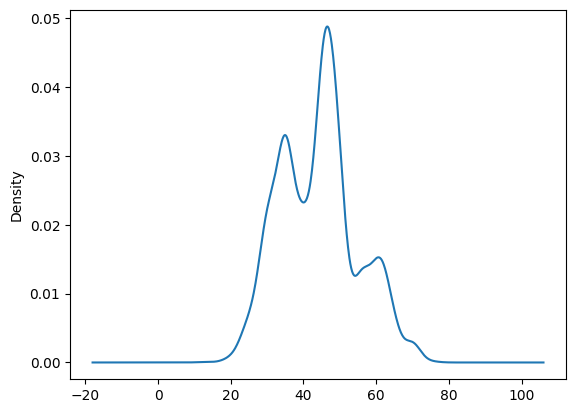

In [20]:
data['mileage_owner_reported'].plot(kind='kde')
data['mileage_owner_reported'].skew()

<Axes: >

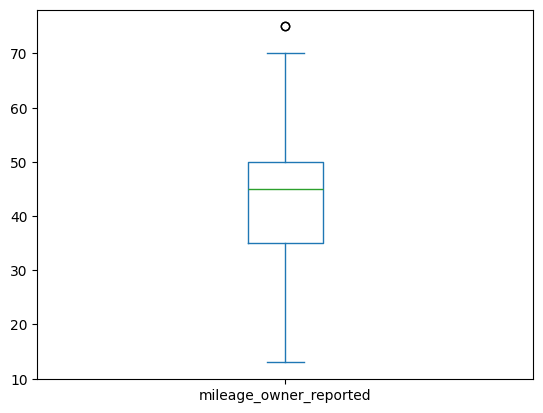

In [21]:
data['mileage_owner_reported'].plot(kind='box')

### --> Riding range 
1. consists of nearly half the missing values so will look later

In [22]:
data['riding_range'].isna().sum()

np.int64(1429)

### --> Cylinders
1. handle 223 mising values
2. there is not much info as mainly the bike contains 1 cylinder but price is high for more number of cylinders

In [23]:
data['cylinders'].isna().sum()

np.int64(224)

In [24]:
data['cylinders'].value_counts()

cylinders
1.0    2408
2.0      79
4.0       4
3.0       1
Name: count, dtype: int64

<Axes: ylabel='Frequency'>

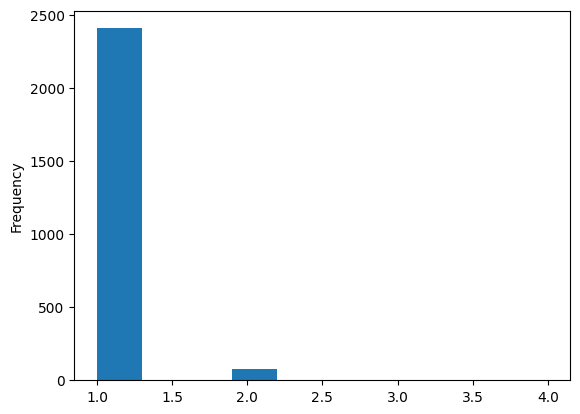

In [25]:
data['cylinders'].plot(kind='hist')

In [26]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2716 entries, 0 to 2715
Data columns (total 20 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   title                   2716 non-null   object 
 1   brand_name              2716 non-null   object 
 2   model                   2716 non-null   object 
 3   bike_age                2716 non-null   int64  
 4   kilometer               2716 non-null   int64  
 5   fuel_type               2716 non-null   object 
 6   owner                   2716 non-null   object 
 7   city                    2716 non-null   object 
 8   color                   2716 non-null   object 
 9   insurance               2716 non-null   object 
 10  mileage_arai            1252 non-null   float64
 11  mileage_owner_reported  2496 non-null   float64
 12  riding_range            1287 non-null   float64
 13  cylinders               2492 non-null   float64
 14  front_brake_type        2716 non-null   

### --> fuel_tank_capacity and reserve_fuel_capacity
1. handle the missng values in both columns 

### --> price
1. there were some bikes with extremely low price like 2k aur 3k which is not possible while other features are not justifying the price.

2. some bikes have extremely low price and they are not even that old , also the km traveled the bike are also not very high.

3. there were some bikes whose prices very insanely high with respect to their company and model so converted prices of those instancs changed to nan.

4. data is skewed towards left but can't really do anything about it.

In [27]:
pd.set_option('display.float_format', lambda x: '%.4f' % x)

In [28]:
data['price'].describe()

count      2716.0000
mean     104577.0865
std      110480.9325
min        2032.0000
25%       45000.0000
50%       75000.0000
75%      136250.0000
max     1700000.0000
Name: price, dtype: float64

In [29]:
data[data['kilometer'].isna()]

,title,brand_name,model,bike_age,kilometer,fuel_type,owner,city,color,insurance,mileage_arai,mileage_owner_reported,riding_range,cylinders,front_brake_type,rear_brake_type,tyre_type,fuel_tank_capacity,reserve_fuel_capacity,price


In [30]:
# removed scooty and activa from dataset as they are not bikes
rem = ['scooty', 'activa']
data1 = data.copy()

for i in rem:
    data1 = data1[~data1['model'].str.lower().str.contains(i.lower())]

print(data1.shape)

(2583, 20)


<Axes: ylabel='Frequency'>

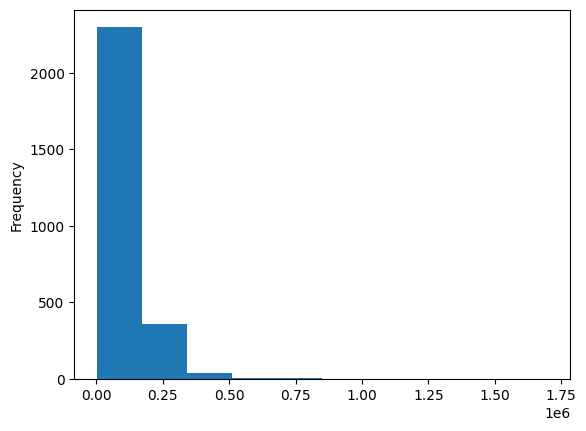

In [31]:
data['price'].plot(kind='hist')

np.float64(6.130381564266253)

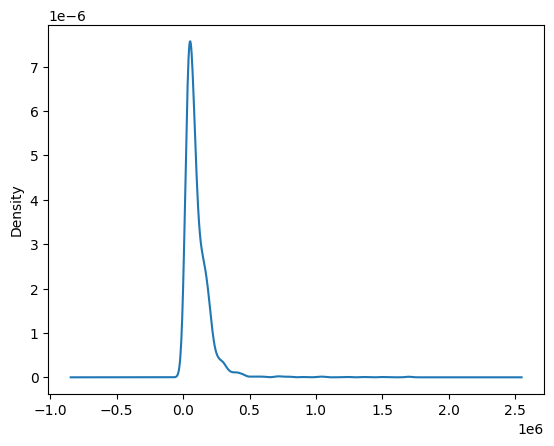

In [32]:
data['price'].plot(kind='kde')
data['price'].skew()

<Axes: >

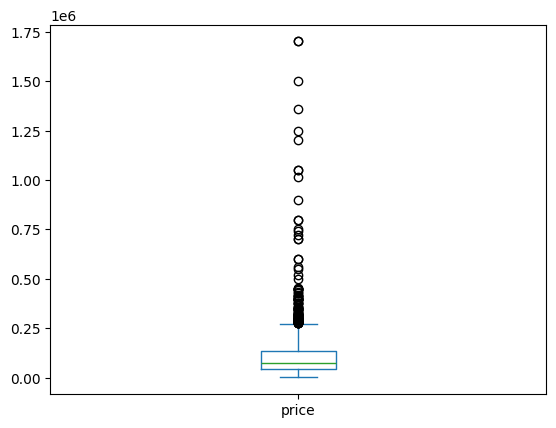

In [33]:
data['price'].plot(kind='box')

In [34]:
pd.set_option('display.max_rows', None)
data[data['price'].isna()]

,title,brand_name,model,bike_age,kilometer,fuel_type,owner,city,color,insurance,mileage_arai,mileage_owner_reported,riding_range,cylinders,front_brake_type,rear_brake_type,tyre_type,fuel_tank_capacity,reserve_fuel_capacity,price


## Filling missing values - 
1. use misisng indicator and then drop mileage_arai column 

2. do the same with riding_range

3. OLA scooters doesn't contain cylinders so there value is nan so need to handle those differently ::: handled by creating a new column is_electric to create a flag 

4. some bikes are electric so there is no reserve fuel capacity and fuel tank capacity so handle accordingly ::: same as point no. 3

5. Manually fill the values of price column as they are less and can be filled easily through research 

6. fill the riding range column by multiplying fuel_capacity and mileage_owner_reported

<Axes: >

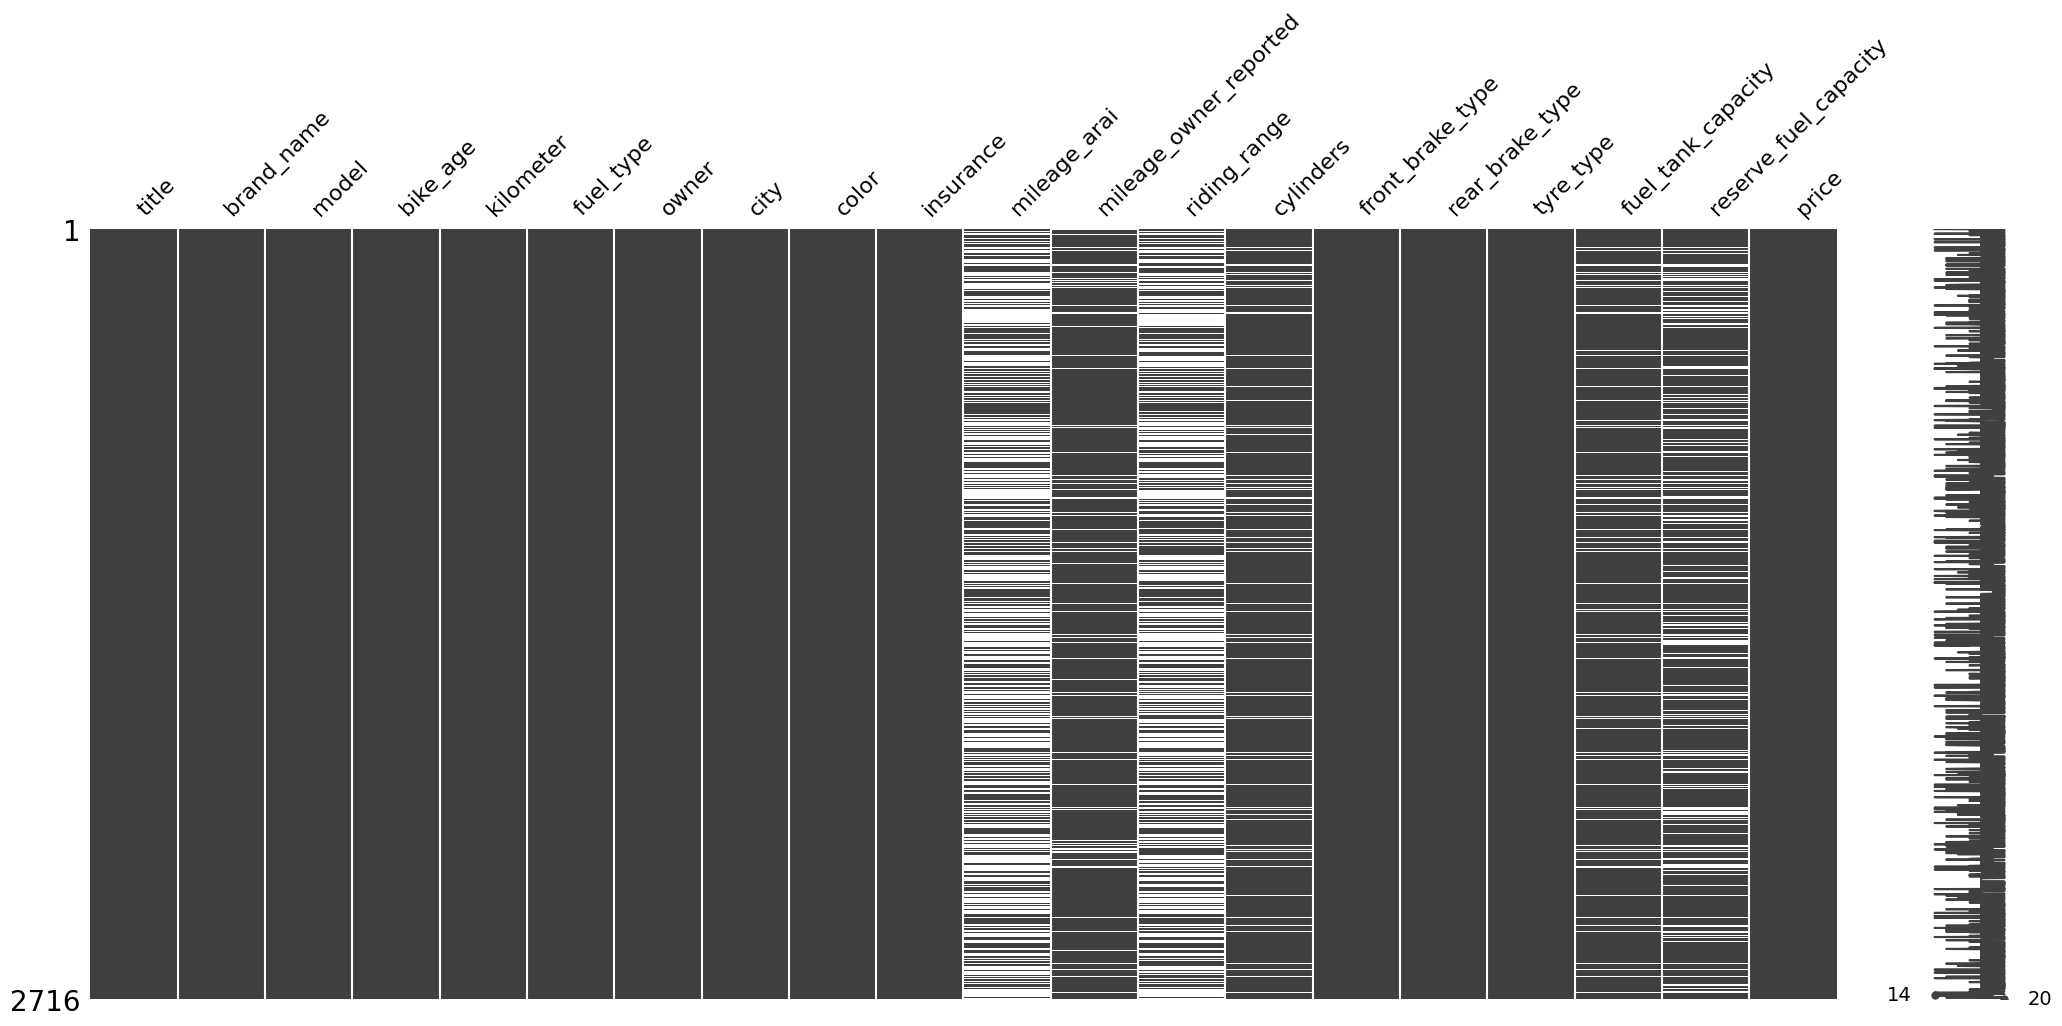

In [35]:
import missingno as msno
msno.matrix(data)

In [36]:
df = data[data['cylinders'].isna()]
df.value_counts('brand_name')

brand_name
Hero Honda       51
OLA              40
Royal Enfield    31
Bajaj            24
Honda            19
Revolt           14
Other            12
TVS              11
Yamaha            8
Hero              6
Ather             5
Suzuki            3
Name: count, dtype: int64

i have to fill royal enf , yamaha

In [37]:
data['cylinders'].value_counts()
data[data['cylinders'] == 1]['brand_name'].value_counts()

brand_name
Bajaj              433
Honda              350
TVS                329
Hero               326
Royal Enfield      287
Yamaha             273
Suzuki             127
KTM                 88
Jawa                68
BMW                 34
Yezdi               22
Triumph             17
Aprilia             12
Vespa               11
Other                9
Mahindra             7
UM                   7
Benelli              4
Harley-Davidson      3
Kawasaki             1
Name: count, dtype: int64

In [61]:
br = ["Yamaha"]
data.loc[(data['brand_name'].isin(br)) & (data['cylinders'].isna()) , 'cylinders'] = 1

In [63]:
data[(data['brand_name'] == 'Yamaha') & (data['cylinders'].isna())]

,title,brand_name,model,bike_age,kilometer,fuel_type,owner,city,color,insurance,...,riding_range,cylinders,front_brake_type,rear_brake_type,tyre_type,fuel_tank_capacity,reserve_fuel_capacity,price,vehicle_type,is_electric


In [62]:
data[data['cylinders'].isna()]['brand_name'].value_counts()

Series([], Name: count, dtype: int64)

In [40]:
data['riding_range'].isna().sum() / len(data)

np.float64(0.5261413843888071)

In [41]:
# classified scooters and bikes
def classify_vehicle(model):
    if 'Activa' in model or 'Access' in model or 'Jupiter' in model or 'Ola' in model or 'Ather' in model:
        return 'scooter'
    else:
        return 'bike'

data1['vehicle_type'] = data1['model'].apply(classify_vehicle)
data = data1

In [42]:
data['is_electric'] = (data['fuel_type'] == 'Electric').astype(int)
data['is_electric'].value_counts()

is_electric
0    2496
1      87
Name: count, dtype: int64

In [43]:
data[(data['fuel_tank_capacity'].isna())& (data['is_electric'] == 0)].shape

(136, 22)

In [44]:
# filled some values of riding range column
data['riding_range'] = data['riding_range'].fillna(data['mileage_owner_reported'] * (data['fuel_tank_capacity'] + data['reserve_fuel_capacity']))

<Axes: >

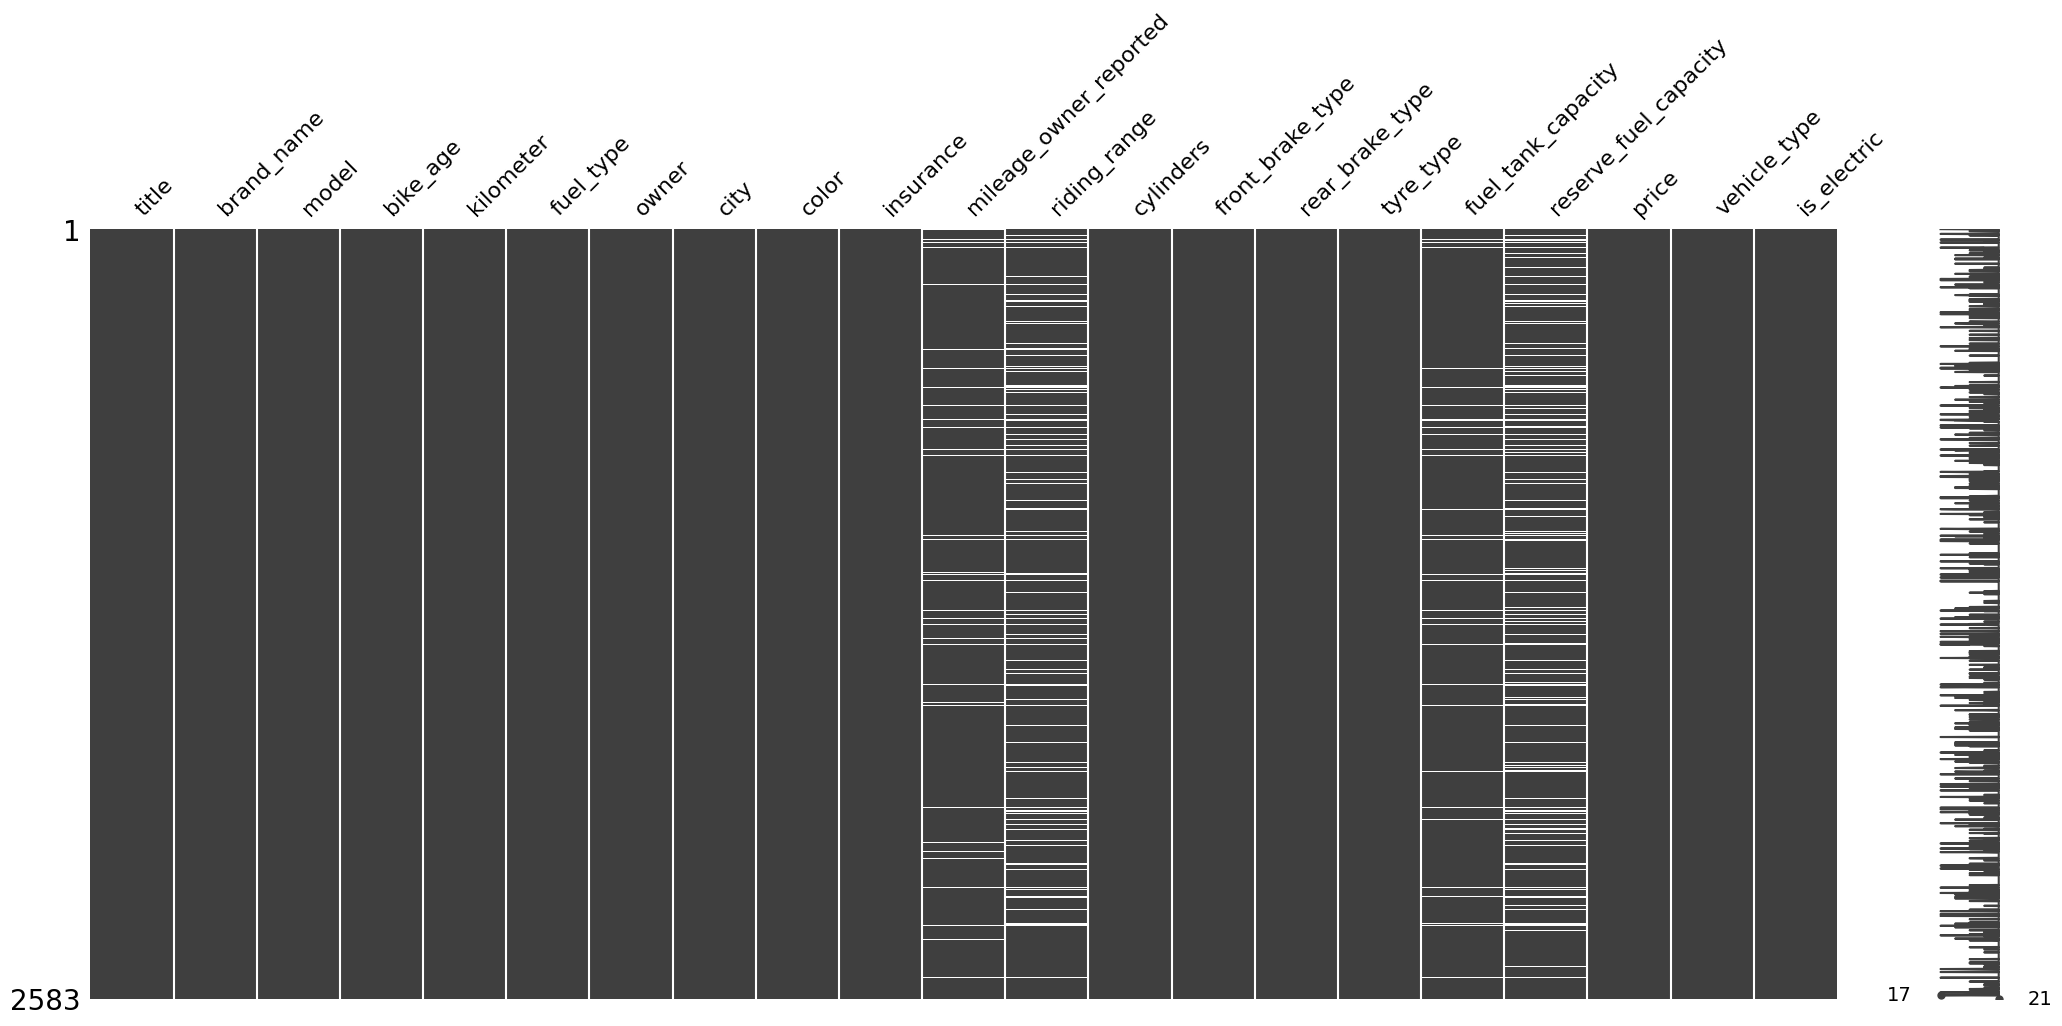

In [79]:
# after filling some missing values
msno.matrix(data)

In [77]:
data.loc[data['is_electric'] == 1, 'mileage_owner_reported'] = 0

1. handles cylinders and only electric bikes are with nan values 

2. also handles most of riding range values but still some values are missing 

3. use multivariate imputer on riding_range , and both tank capacities 

4. use simple imputer techiques on mileage

In [67]:
data[data['fuel_tank_capacity'] == 0]['brand_name'].value_counts()

brand_name
OLA       40
Other     16
Revolt    14
Ather      5
TVS        5
Bajaj      3
Hero       2
Yamaha     1
Suzuki     1
Name: count, dtype: int64

In [72]:
data[(data['is_electric'] == 1) & (data['brand_name'] == 'TVS')]

,title,brand_name,model,bike_age,kilometer,fuel_type,owner,city,color,insurance,...,riding_range,cylinders,front_brake_type,rear_brake_type,tyre_type,fuel_tank_capacity,reserve_fuel_capacity,price,vehicle_type,is_electric
953,2023 TVS iQube ST - 3.4 kWh,TVS,iQube ST - 3.4 kWh,3,40009,Electric,First,Hyderabad,Titanium Grey - Matte,Not Available,...,100.0000,0.0000,Disc,Drum,Tubeless,0.0000,0.0000,65000.0000,bike,1
999,2024 TVS iQube S - 3.4 kWh,TVS,iQube S - 3.4 kWh,2,16500,Electric,First,Jaipur,Mercury Grey,Comprehensive,...,100.0000,0.0000,Disc,Drum,Tubeless,0.0000,0.0000,100000.0000,bike,1
1120,2022 TVS iQube S 3.5 kWh,TVS,iQube S 3.5 kWh,4,5228,Electric,First,Bangalore,Mercury Grey,Comprehensive,...,145.0000,0.0000,Disc,Drum,Tubeless,0.0000,0.0000,115000.0000,bike,1
1784,2023 TVS iQube S - 3.4 kWh,TVS,iQube S - 3.4 kWh,3,7800,Electric,First,Mumbai,Grey,Comprehensive,...,100.0000,0.0000,Disc,Drum,Tubeless,0.0000,0.0000,100000.0000,bike,1
2188,2024 TVS iQube 2.2 kWh [2024],TVS,iQube 2.2 kWh [],2,1100,Electric,First,Kolkata,Pearl White,Comprehensive,...,75.0000,0.0000,Disc,Drum,Tubeless,0.0000,0.0000,120000.0000,bike,1


In [ ]:
data.loc[data['is_electric'] == 1, ['cylinders' , 'fuel_tank_capacity' , 'reserve_fuel_capacity']] = 0
data.drop(columns = ['mileage_arai'] , inplace = True)


In [73]:
data.isnull().mean()*100

title                     0.0000
brand_name                0.0000
model                     0.0000
bike_age                  0.0000
kilometer                 0.0000
fuel_type                 0.0000
owner                     0.0000
city                      0.0000
color                     0.0000
insurance                 0.0000
mileage_owner_reported    8.2075
riding_range             13.3953
cylinders                 0.0000
front_brake_type          0.0000
rear_brake_type           0.0000
tyre_type                 0.0000
fuel_tank_capacity        5.2652
reserve_fuel_capacity    17.1119
price                     0.0000
vehicle_type              0.0000
is_electric               0.0000
dtype: float64

In [89]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import SimpleImputer , IterativeImputer
from sklearn.ensemble import ExtraTreesRegressor

proxy = data

simp_imp = SimpleImputer(strategy= 'median')
petrol_mask = proxy['is_electric'] == 0
proxy['mileage_owner_reported'] = simp_imp.fit_transform(proxy[['mileage_owner_reported']])

iter_imp = IterativeImputer(ExtraTreesRegressor(n_estimators= 60 , random_state=42) , max_iter= 10 , random_state= 42)
cols = ['riding_range' , 'fuel_tank_capacity' , 'reserve_fuel_capacity']
proxy.loc[petrol_mask , cols] = iter_imp.fit_transform(proxy.loc[petrol_mask , cols])

In [87]:
data.to_csv('bikes_data_cleaned.csv', index=False)

<Axes: >

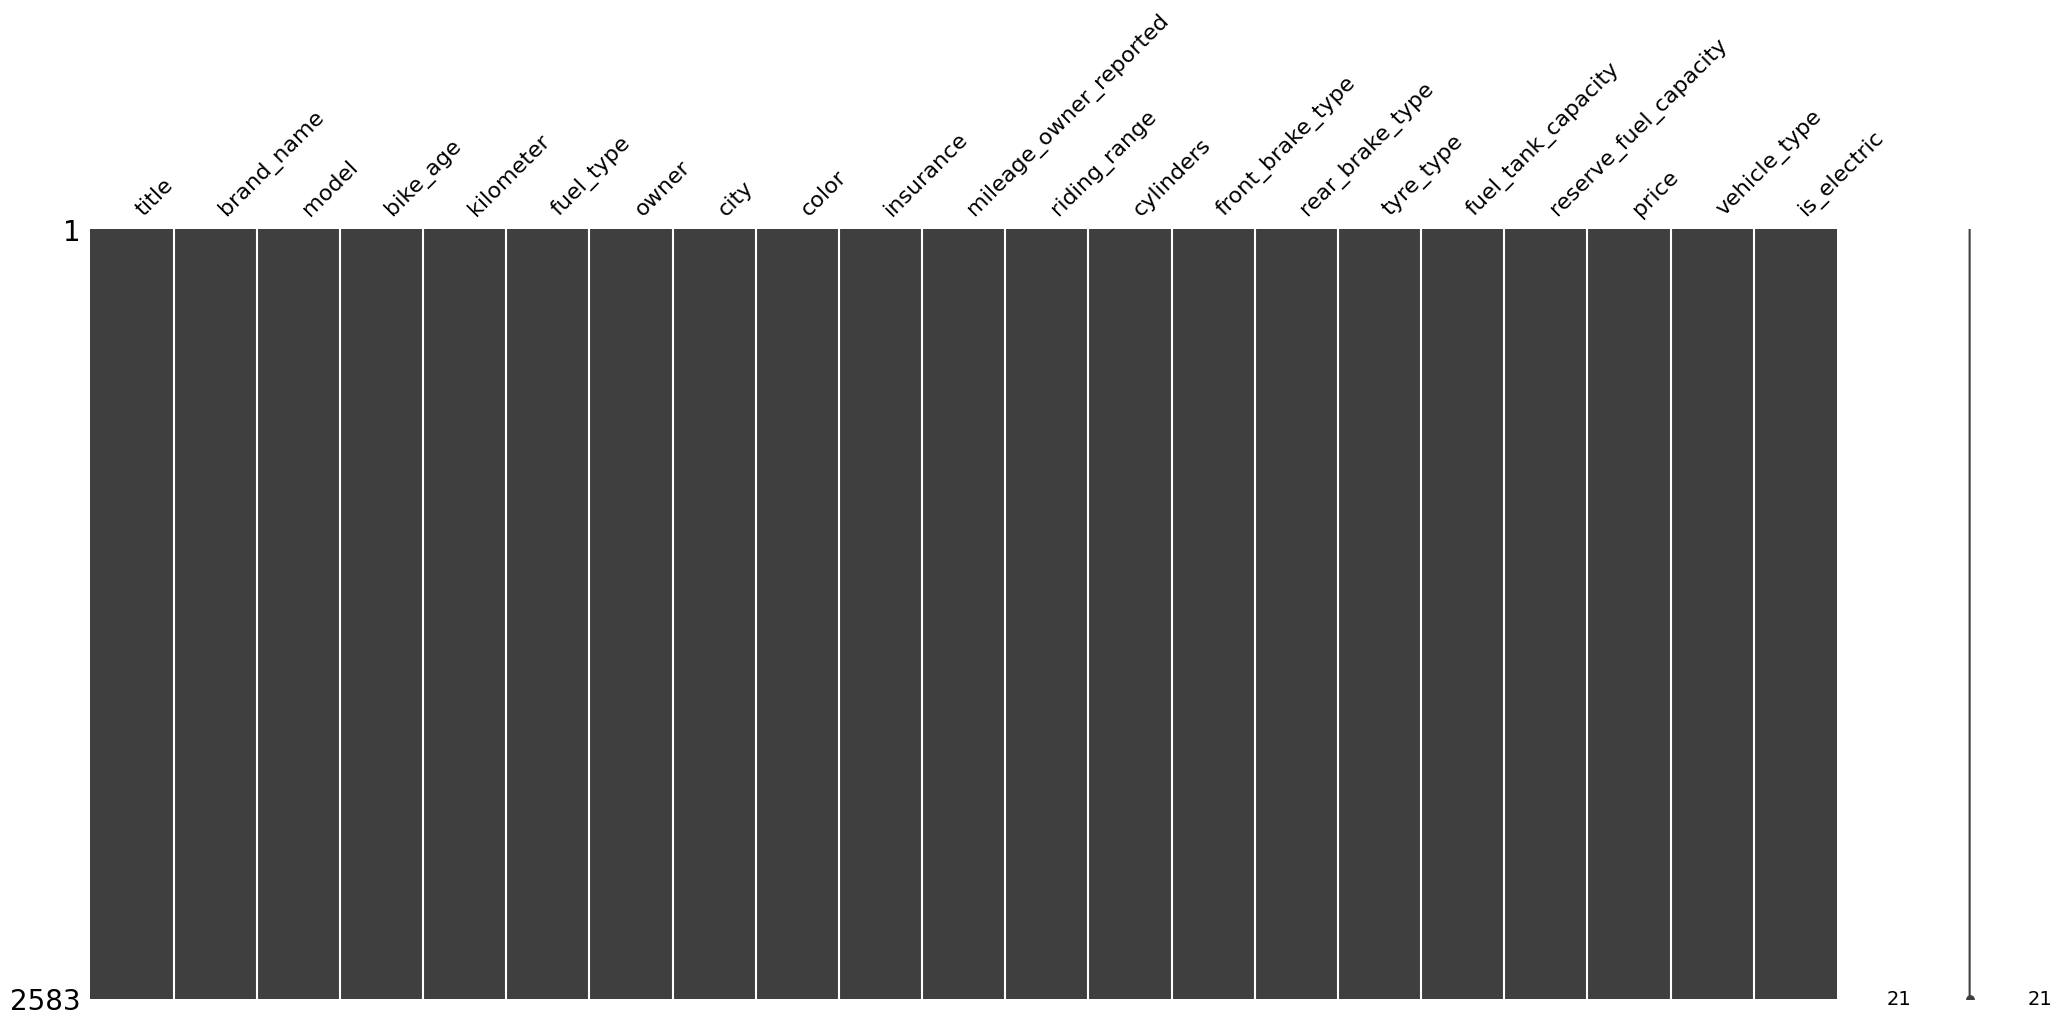

In [6]:
msno.matrix(data)

In [5]:
import pandas as pd
import numpy as np
data = pd.read_csv('/Users/gopesh/Documents/Machine Learning/PROJECTS/bikes_data_cleaned.csv')
data.columns

Index(['title', 'brand_name', 'model', 'bike_age', 'kilometer', 'fuel_type',
       'owner', 'city', 'color', 'insurance', 'mileage_owner_reported',
       'riding_range', 'cylinders', 'front_brake_type', 'rear_brake_type',
       'tyre_type', 'fuel_tank_capacity', 'reserve_fuel_capacity', 'price',
       'vehicle_type', 'is_electric'],
      dtype='object')

## Encoding the categorical features

In [7]:
cat_cols = ['brand_name', 'fuel_type' , 'owner' , 'city' , 'front_brake_type' , 'rear_brake_type' , 'tyre_type' , 'vehicle_type']
cat_cols

['brand_name',
 'fuel_type',
 'owner',
 'city',
 'front_brake_type',
 'rear_brake_type',
 'tyre_type',
 'vehicle_type']